In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchvision.models import ResNet50_Weights, EfficientNet_B0_Weights, Inception_V3_Weights
import warnings
warnings.filterwarnings("ignore")

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

In [5]:
!unzip -q "/content/archive (2).zip" -d /content/

In [6]:
train = datasets.ImageFolder("NEU-DET/train/images", transform=transform)
test  = datasets.ImageFolder("NEU-DET/validation/images", transform=transform)

train_loader = DataLoader(train, batch_size=32, shuffle=True)
test_loader  = DataLoader(test, batch_size=32)

In [7]:
def train_model(model):
    for p in model.parameters():
        p.requires_grad = False

    if hasattr(model, 'fc'):
        model.fc = nn.Linear(model.fc.in_features, 6)
    elif hasattr(model, 'classifier'):
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

    model = model.to(device)

    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    loss_history = []
    acc_history = []

    for epoch in range(5):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            out = model(x)
            if isinstance(out, tuple):
                out = out[0]
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()

            total_loss += loss.item()

            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

        epoch_loss = total_loss / len(train_loader)
        epoch_acc = correct / total

        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)

        print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            out = model(x)
            pred = out.argmax(1)
            correct += (pred.cpu() == y).sum().item()
            total += y.size(0)

    test_acc = correct / total
    print("Test Accuracy:", test_acc)

    return loss_history, acc_history, test_acc

In [8]:
def plot_graph(loss, acc, title):
    plt.figure()
    plt.plot(loss, label="Loss")
    plt.plot(acc, label="Accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


Epoch 1 | Loss: 0.9578 | Acc: 0.7701
Epoch 2 | Loss: 0.3162 | Acc: 0.9750
Epoch 3 | Loss: 0.2010 | Acc: 0.9708
Epoch 4 | Loss: 0.1543 | Acc: 0.9812
Epoch 5 | Loss: 0.1219 | Acc: 0.9806
Test Accuracy: 0.9916666666666667


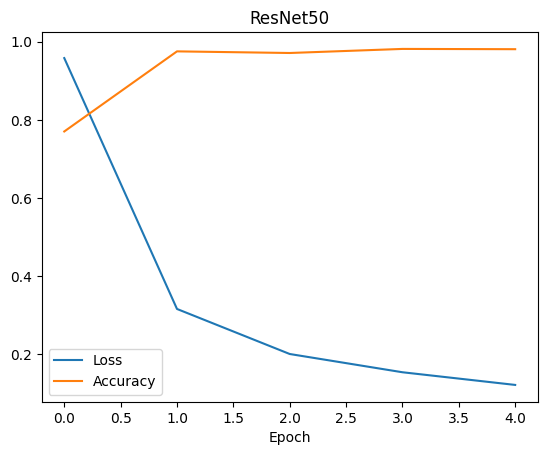

In [9]:
resnet = models.resnet50(weights=ResNet50_Weights.DEFAULT)
loss, acc, res_acc = train_model(resnet)
plot_graph(loss, acc, "ResNet50")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


Epoch 1 | Loss: 0.8300 | Acc: 0.8292
Epoch 2 | Loss: 0.2654 | Acc: 0.9597
Epoch 3 | Loss: 0.1808 | Acc: 0.9694
Epoch 4 | Loss: 0.1464 | Acc: 0.9743
Epoch 5 | Loss: 0.1209 | Acc: 0.9743
Test Accuracy: 0.9833333333333333


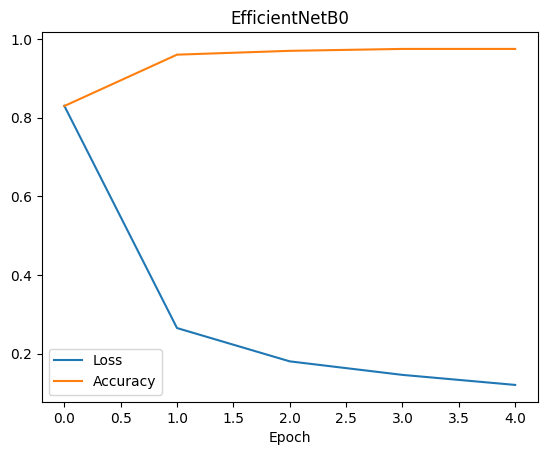

In [10]:
efficient = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
loss, acc, eff_acc = train_model(efficient)
plot_graph(loss, acc, "EfficientNetB0")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 130MB/s]


Epoch 1 | Loss: 1.0333 | Acc: 0.6910
Epoch 2 | Loss: 0.3693 | Acc: 0.9437
Epoch 3 | Loss: 0.2660 | Acc: 0.9465
Epoch 4 | Loss: 0.2057 | Acc: 0.9563
Epoch 5 | Loss: 0.1792 | Acc: 0.9583
Test Accuracy: 0.9638888888888889


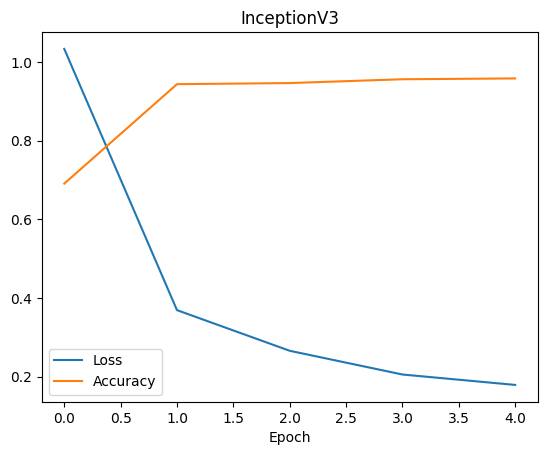

In [11]:
inception = models.inception_v3(weights=Inception_V3_Weights.DEFAULT)
loss, acc, inc_acc = train_model(inception)
plot_graph(loss, acc, "InceptionV3")

In [12]:
print("\nFinal Results:")
print("ResNet50:", res_acc)
print("EfficientNetB0:", eff_acc)
print("InceptionV3:", inc_acc)


Final Results:
ResNet50: 0.9916666666666667
EfficientNetB0: 0.9833333333333333
InceptionV3: 0.9638888888888889
